In [1]:
import numpy as np
import pandas as pd
import re
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag
import torch
import torch.nn as nn
from torch.optim import Adam
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [2]:
device = 'cuda' if torch.cuda.is_available() else "cpu"
print(f"Available device is: {device}")

Available device is: cuda


In [3]:
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\shree\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\shree\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\shree\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [4]:
df = pd.read_csv(r"D:\Work_Station\DeeplearningBasics\data\mercor_ai\train.csv")
df.drop(["id"], inplace = True, axis = 1)
df.head()

,topic,answer,is_cheating
0,A girl wakes from a dream and she is not sure ...,"My eyes flew open, and the air around me feels...",1
1,A journalistic review piece about the top 6 ai...,Robot Butlers in the year of 2025. What are th...,0
2,The influence of fictional universities in cam...,"In recent years, apparel featuring the names a...",1
3,Why do girls love horses,"The moment before I hit the dirt, I thought we...",0
4,"Every year, a remote mountain town elects a ne...","In the valley of Eldermist, were the mountains...",1


In [5]:
df.shape
df.isnull().sum()

topic          0
answer         0
is_cheating    0
dtype: int64

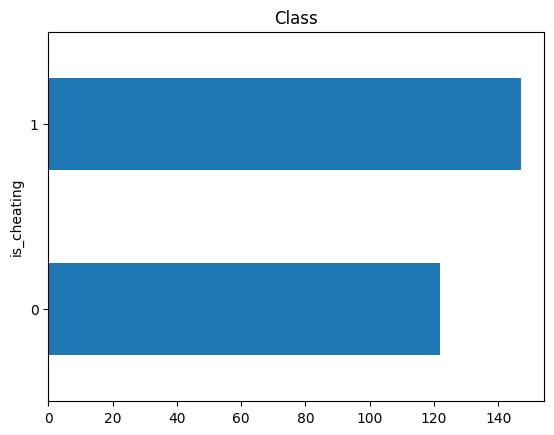

In [6]:
label_counts = df['is_cheating'].value_counts(ascending=True)
label_counts.plot.barh()
plt.title("Class")
plt.show()

In [7]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

In [8]:
import re

def clean_text(text):
    """
    Cleans the input text by:
    - Lowercasing
    - Removing numbers and special characters
    - Stripping extra spaces
    """
    if not isinstance(text, str):
        return ""
    
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    return text


In [9]:
df["cleaned_topic"] = df["topic"].apply(clean_text)

print(df["topic"][5])
print(df["cleaned_topic"][5])

True paranormal story from my childhood- the picture frame
true paranormal story from my childhood the picture frame


In [10]:
df["combined_text"] = (
    df["topic"].apply(clean_text) + " " +
    df["answer"].apply(clean_text)
)

In [11]:
df.drop(["topic", "answer", "cleaned_topic"], inplace = True, axis = 1)

In [12]:
df.columns

Index(['is_cheating', 'combined_text'], dtype='object')

In [13]:
X = df["combined_text"]     
y = df["is_cheating"]

In [14]:
# Step 1: 80% train, 20% temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    np.array(X), np.array(y), test_size=0.2, random_state=42, stratify=y
)

# Step 2: Split 20% temp into 10% val, 10% test (equal halves)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

print(f"Training Size: {X_train.shape[0]}, Which is: {round(X_train.shape[0]/df.shape[0]*100, 2)}%")
print(f"Validation Size: {X_val.shape[0]}, Which is: {round(X_val.shape[0]/df.shape[0]*100, 2)}%")
print(f"Test Size: {X_test.shape[0]}, Which is: {round(X_test.shape[0]/df.shape[0]*100, 2)}%")

Training Size: 215, Which is: 79.93%
Validation Size: 27, Which is: 10.04%
Test Size: 27, Which is: 10.04%


In [15]:
from transformers import AutoTokenizer, AutoModel

# This will download to Kaggle cache
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
model = AutoModel.from_pretrained("distilbert-base-uncased")


## Dataset Object Class

In [16]:
class dataset(Dataset):
    def __init__(self, X, Y, tokenizer, max_len=100):
        self.X = X                                  # store raw text
        self.Y = torch.tensor(Y, dtype=torch.float32)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        # Tokenize the text here
        encoded = self.tokenizer(
            self.X[index],
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors='pt'
        )

        # Prepare the inputs
        x = {k: v.squeeze(0) for k, v in encoded.items()}
        y = self.Y[index]
        return x, y


In [17]:
training_data = dataset(X_train, y_train, tokenizer, max_len=128)
validation_data = dataset(X_val, y_val, tokenizer, max_len=128)
test_data = dataset(X_test, y_test, tokenizer, max_len=128)

## Data Loader
- To create a [batch size] of the data we create DataLoader
- It is an object that we use to do the for loop during each epoch, to loop through the specific amount of batches

In [18]:
### Hyperparameters

BATCH_SIZE = 32
EPOCHS =10
LR = 1e-4

In [19]:
train_dataloader = DataLoader(training_data, batch_size = BATCH_SIZE, shuffle = True)
validation_dataloader = DataLoader(validation_data, batch_size = BATCH_SIZE)
test_dataloader = DataLoader(test_data, batch_size = BATCH_SIZE)

## Building Module

In [20]:
class MyModel(nn.Module):
    def __init__(self, bert):
        super(MyModel, self).__init__()
        self.bert = bert
        self.dropout = nn.Dropout(0.25)
        self.linear1 = nn.Linear(768, 384)
        self.linear2 = nn.Linear(384, 1)  # keep only this
        # remove self.sigmoid

    def forward(self, input_ids, attention_mask):  
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            return_dict=False
        )
        pooled_output = outputs[0][:, 0, :]
        output = self.linear1(pooled_output)
        output = torch.relu(output)
        output = self.dropout(output)
        output = self.linear2(output)
        return output  # no sigmoid


In [21]:
# Freeze BERT parameters
for param in model.parameters():
    param.requires_grad = False

bert_model = MyModel(model).to(device)

In [22]:
bert_model

MyModel(
  (bert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): DistilBertSdpaAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
            (lin1): Linear(in_feat

## Loss Function

In [23]:
criterion = nn.BCEWithLogitsLoss()
optimizer = Adam(bert_model.parameters(), lr = LR)

In [24]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    # ------------------- TRAINING -------------------
    bert_model.train()
    for indx, data in enumerate(train_dataloader):
        inputs, labels = data

        # Move to device
        inputs = {k: v.to(device) for k, v in inputs.items()}
        labels = labels.to(device)

        # Forward pass
        prediction = bert_model(
            inputs["input_ids"],
            inputs["attention_mask"]
        ).squeeze()

        # Compute loss
        batch_loss = criterion(prediction, labels)
        total_loss_train += batch_loss.item()

        # Compute accuracy
        acc = (prediction.round() == labels).sum().item()
        total_acc_train += acc

        # Backprop
        optimizer.zero_grad()
        batch_loss.backward()
        optimizer.step()

    # ------------------- VALIDATION -------------------
    bert_model.eval()  # ✅ use bert_model, not model
    with torch.no_grad():
        for indx, data in enumerate(validation_dataloader):
            inputs, labels = data
            inputs = {k: v.to(device) for k, v in inputs.items()}
            labels = labels.to(device)

            prediction = bert_model(
                inputs["input_ids"],
                inputs["attention_mask"]
            ).squeeze()

            batch_loss = criterion(prediction, labels)
            total_loss_val += batch_loss.item()

            acc = (prediction.round() == labels).sum().item()
            total_acc_val += acc

    # ------------------- METRICS STORAGE -------------------
    total_loss_train_plot.append(round(total_loss_train / len(train_dataloader), 4))
    total_loss_validation_plot.append(round(total_loss_val / len(validation_dataloader), 4))
    total_acc_train_plot.append(round((total_acc_train / len(training_data)) * 100, 4))
    total_acc_validation_plot.append(round((total_acc_val / len(validation_data)) * 100, 4))

    # ------------------- PRINT RESULTS -------------------
    print(f"""
    Epoch {epoch + 1}/{EPOCHS}
    --------------------------
    Train Loss: {total_loss_train_plot[-1]} | Train Acc: {total_acc_train_plot[-1]}%
    Val Loss:   {total_loss_validation_plot[-1]} | Val Acc:   {total_acc_validation_plot[-1]}%
    """)



    Epoch 1/10
    --------------------------
    Train Loss: 0.6767 | Train Acc: 45.5814%
    Val Loss:   0.6627 | Val Acc:   44.4444%
    

    Epoch 2/10
    --------------------------
    Train Loss: 0.6552 | Train Acc: 45.5814%
    Val Loss:   0.6367 | Val Acc:   44.4444%
    

    Epoch 3/10
    --------------------------
    Train Loss: 0.633 | Train Acc: 46.5116%
    Val Loss:   0.6119 | Val Acc:   48.1481%
    

    Epoch 4/10
    --------------------------
    Train Loss: 0.6095 | Train Acc: 51.6279%
    Val Loss:   0.5899 | Val Acc:   44.4444%
    

    Epoch 5/10
    --------------------------
    Train Loss: 0.5846 | Train Acc: 56.7442%
    Val Loss:   0.5654 | Val Acc:   48.1481%
    

    Epoch 6/10
    --------------------------
    Train Loss: 0.5631 | Train Acc: 64.186%
    Val Loss:   0.5426 | Val Acc:   51.8519%
    

    Epoch 7/10
    --------------------------
    Train Loss: 0.5412 | Train Acc: 60.4651%
    Val Loss:   0.5218 | Val Acc:   40.7407%
    

    Epo

Training Summary Per Epoch:

   Epoch  Train Loss  Val Loss  Train Acc (%)  Val Acc (%)
0      1      0.6767    0.6627        45.5814      44.4444
1      2      0.6552    0.6367        45.5814      44.4444
2      3      0.6330    0.6119        46.5116      48.1481
3      4      0.6095    0.5899        51.6279      44.4444
4      5      0.5846    0.5654        56.7442      48.1481
5      6      0.5631    0.5426        64.1860      51.8519
6      7      0.5412    0.5218        60.4651      40.7407
7      8      0.5163    0.5000        56.2791      48.1481
8      9      0.4955    0.4803        58.1395      48.1481
9     10      0.4737    0.4605        59.0698      48.1481


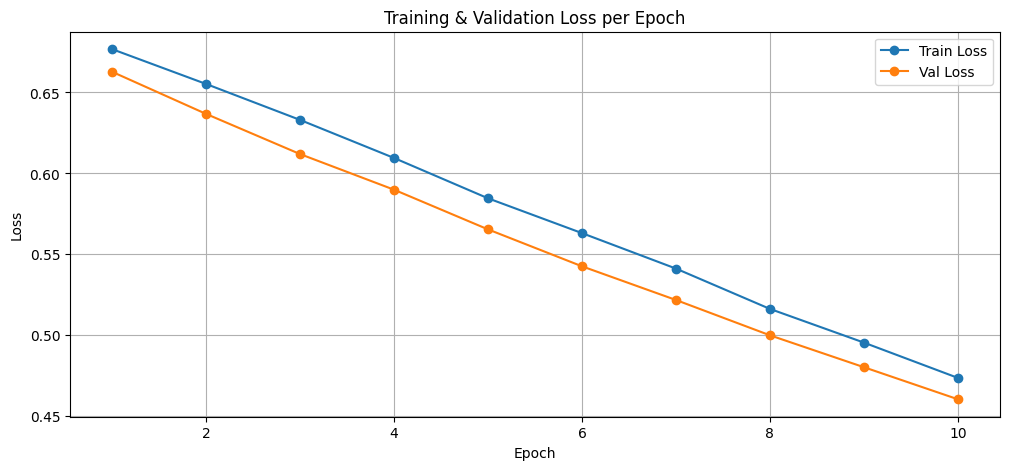

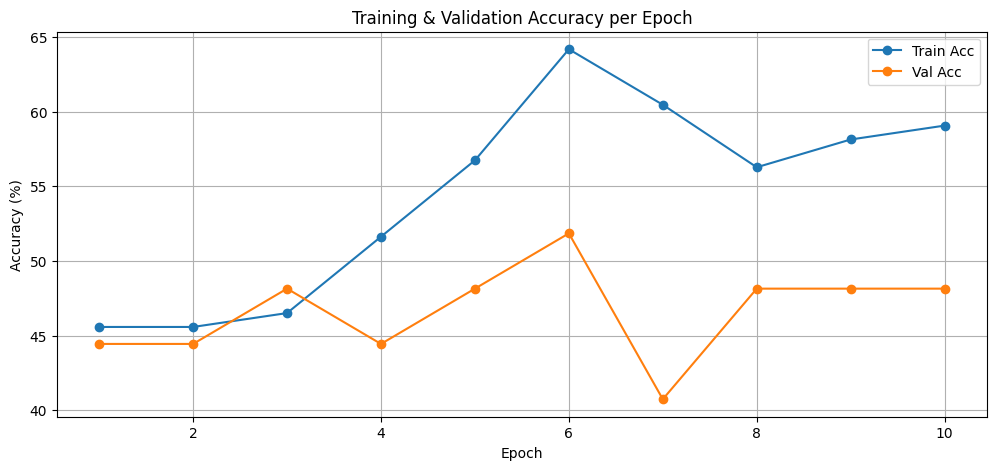

In [25]:
# 1️⃣ Create a DataFrame for all epochs
epochs = list(range(1, len(total_loss_train_plot) + 1))
results_df = pd.DataFrame({
    "Epoch": epochs,
    "Train Loss": total_loss_train_plot,
    "Val Loss": total_loss_validation_plot,
    "Train Acc (%)": total_acc_train_plot,
    "Val Acc (%)": total_acc_validation_plot
})

# 2️⃣ Display all records
print("Training Summary Per Epoch:\n")
print(results_df)

# 3️⃣ Plot losses
plt.figure(figsize=(12,5))
plt.plot(results_df["Epoch"], results_df["Train Loss"], label="Train Loss", marker='o')
plt.plot(results_df["Epoch"], results_df["Val Loss"], label="Val Loss", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss per Epoch")
plt.legend()
plt.grid(True)
plt.show()

# 4️⃣ Plot accuracies
plt.figure(figsize=(12,5))
plt.plot(results_df["Epoch"], results_df["Train Acc (%)"], label="Train Acc", marker='o')
plt.plot(results_df["Epoch"], results_df["Val Acc (%)"], label="Val Acc", marker='o')
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training & Validation Accuracy per Epoch")
plt.legend()
plt.grid(True)
plt.show()


## Test Data

In [26]:
test_df  = pd.read_csv(r"D:\Work_Station\DeeplearningBasics\data\mercor_ai\test.csv")
sample_submission = pd.read_csv(r"D:\Work_Station\DeeplearningBasics\data\mercor_ai\sample_submission.csv")

In [27]:
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

In [28]:
test_df["combined_text"] = test_df["topic"].astype(str) + " " + test_df["answer"].astype(str)

In [29]:
class TestDataset(Dataset):
    def __init__(self, X, tokenizer, max_len=128):
        self.X = X
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.X)

    def __getitem__(self, index):
        encoded = self.tokenizer(
            self.X[index],
            max_length=self.max_len,
            truncation=True,
            padding="max_length",
            return_tensors='pt'
        )
        return {k: v.squeeze(0) for k, v in encoded.items()}


In [30]:
# ✅ Clean and combine text
test_df["combined_text"] = test_df["topic"].astype(str) + " " + test_df["answer"].astype(str)
test_texts = test_df["combined_text"].apply(clean_text).tolist()

# ✅ Create test dataset and dataloader
test_dataset = TestDataset(test_texts, tokenizer, max_len=128)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# ✅ Run inference
bert_model.eval()
predictions = []
with torch.no_grad():
    for batch in test_loader:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = bert_model(batch["input_ids"], batch["attention_mask"]).squeeze()
        preds = (torch.sigmoid(outputs).cpu().numpy() >= 0.5).astype(int)
        predictions.extend(preds)


In [31]:
submission = sample_submission.copy()
submission["is_cheating"] = [int(p) for p in predictions]
submission.to_csv("submission.csv", index=False)
print("✅ submission.csv saved successfully for Kaggle!")


✅ submission.csv saved successfully for Kaggle!
